# Parameter search for first excited state of a 1D quantum harmonic oscillator

**NOTE**: The code in this notebook takes a long time to run. Therefore, we have saved the results to files after running it once. 
You can load the results from the file directly instead of running the code again by setting the below `LOAD_FROM_FILE` variable to `True`.

In [1]:
LOAD_FROM_FILE = True

In [2]:
# Parameter search for first excited state of a 1D quantum harmonic oscillator
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from typing import Callable
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import torch
from torch import nn
from utils.utils import generate_input_data
from utils.cell_magic import skip_if
from param_search.A_train_ground_state import load_ground_state_pinn
from core.grid_search import grid_search
from core.training import train_tise
from tise1d.tise1d import PotentialHarmonicOscillator, Loss_Orthogonality, Loss_PDE, ansatzfactor_HO_sym
from tise1d.analytic_ho import compare_analytic

plt.style.use('./utils/_plot_style.mplstyle')

In [3]:
# Check for available gpu
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [4]:
# Parameters used throughout the project
x_lim = (-5.0, 5.0)
N_samples = 256

# Generate data points
torch.manual_seed(124)
x = generate_input_data(N_samples, x_lim, device)
x_test = generate_input_data(N_samples, x_lim, device)

# Load ground state PINN to use in orthogonality loss constraint
pinn1 = load_ground_state_pinn(device)

In [5]:
# Set up for parameter search
def train_func(x: torch.Tensor, ortho_loss_weight: float, **kwargs):
    return train_tise(
        x,
        **kwargs,
        loss_func=Loss_PDE(PotentialHarmonicOscillator())+ortho_loss_weight*Loss_Orthogonality([pinn1]),
    )
def generate_data_func():
    return generate_input_data(256, x_lim, "cpu").numpy()

## Random search
We first perform a random search over the following hyperparameters to get a general sense of which hyperparameters work well for this problem:
- learning rate
- learning rate energy
- ortho loss weight

The random search was performed using "Weights and Biases" (wandb). The code below shows how the random search was set up. 

```python

In [6]:
# Load data from Weights and Biases export
df = pd.read_csv("../data/random_sweep_results.csv")
df["Loss_sum"] = df["Loss_PDE"] + df["Loss_Orthogonality"]
df.head()

,learning_rate,learning_rate_energy,ortho_loss_weight,Loss_Orthogonality,Loss_PDE,Loss_Energy,Loss_sum
0,0.000012,0.001557,552.896031,0.016709,0.029300,0.008687,0.046009
1,0.000124,0.013647,158.360520,0.015471,0.004678,0.000492,0.020148
2,0.000072,0.518900,101.967418,0.015246,0.003639,0.000433,0.018885
3,0.001087,0.002613,1037.997492,0.016134,0.022631,0.007085,0.038766
4,0.001797,0.477727,1513.969304,0.016271,0.031941,0.010385,0.048212


In [7]:


def plot_random_search_metrics_twinx(df: pd.DataFrame, x_axes=["learning_rate", "learning_rate_energy", "ortho_loss_weight"], metrics=["Loss_PDE", "Loss_Orthogonality"], s=5, alpha=0.3, xscale="log", yscale="log"):

    fig, axes = plt.subplots(1, len(x_axes), figsize=(6*len(x_axes), 5))
    if not hasattr(axes, "__getitem__"):
        axes = [axes]

    legend_handles = []

    for i, x_axis in enumerate(x_axes):
        base_ax = axes[i]
        base_ax.set_xscale(xscale)
        for j, metric in enumerate(metrics):
            # Legend handles
            if i == 0:
                legend_handles.append(Line2D([0], [0], marker='o', color='w', label=metric,markerfacecolor=f"C{j}", markersize=8))

            # Create twin axes
            ax = base_ax if j == 0 else base_ax.twinx()
            
            ax.set_xlabel(x_axis)

            ax.scatter(df[x_axis], df[metric], alpha=alpha, s=s, color=f"C{j}")
            ax.set_yscale(yscale)

            # --- Color ticks *and* tick marks *and* axis spine ---
            ax.tick_params(axis='y', colors=f"C{j}", which="both")  # colors tick labels + marks (if visible)

            # Ensure tick MARK LINES are colored (sometimes the above fails)
            for tickline in ax.yaxis.get_ticklines():
                tickline.set_color(f"C{j}")

            # Color the visible y-axis spine
            spine = 'left' if j == 0 else 'right'
            ax.spines[spine].set_color(f"C{j}")

        
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(metrics),
        frameon=True,
        bbox_to_anchor=(0.5, 1.0)  # adjust vertical spacing
    )

    plt.tight_layout(rect=(0, 0.0, 1, 1))  # reserve extra margin below


def plot_colormap_plot(df: pd.DataFrame, metrics=["Loss_PDE", "Loss_Orthogonality"], x="learning_rate", y="learning_rate_energy", s=20, alpha=0.5, color_scale="log", vmax=None):
    fig, axes = plt.subplots(len(metrics), 1, figsize=(7, 5*len(metrics)))
    if not hasattr(axes, "__getitem__"):
        axes = [axes]
    for i, metric in enumerate(metrics):
            
        ax = axes[i]
        vmin = df[metric].min()
        if vmin <= 0:
            vmin = df[df[metric]!=0][metric].min() # LogNorm requires positive values
            
        log_norm = mcolors.LogNorm(vmin=vmin, vmax=vmax if vmax else df[metric].max())
        scatter = ax.scatter(df[x], df[y], alpha=alpha, s=s, c=df[metric], cmap="viridis", norm=log_norm if color_scale=="log" else None)
        fig.colorbar(scatter, ax=ax, label=f"{metric}")
        ax.set_xscale("log")
        ax.set_yscale("log")

        if i == len(metrics)-1:
            ax.set_xlabel(x)
            ax.set_ylabel(y)
    plt.tight_layout()

def plot_3dscatter(df, params, metric, s=20, alpha=0.5):
    x, y, z = params
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(
        np.log10(df[x]), np.log10(df[y]), np.log10(df[z]),
        c=np.log10(df[metric]), cmap="viridis",
        s=s, alpha=alpha
    )
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_zlabel(z)
    cbar = fig.colorbar(sc, ax=ax, shrink=0.7)
    cbar.set_label(metric)
    return fig, ax

def plot_interactive_3dscatter(df, params, metric, s=5, alpha=0.5):
    import plotly.express as px
    x, y, z = params
    fig = px.scatter_3d(
        df,
        x=np.log10(df[x]),
        y=np.log10(df[y]),
        z=np.log10(df[z]),
        color=np.log10(df[metric]),
        color_continuous_scale="Viridis",
        opacity=alpha,
        size_max=s,
    )
    fig.update_layout(
        scene = dict(
            xaxis_title=x,
            yaxis_title=y,
            zaxis_title=z
        ),
        coloraxis_colorbar=dict(
            title=metric
        )
    )
    fig.show()


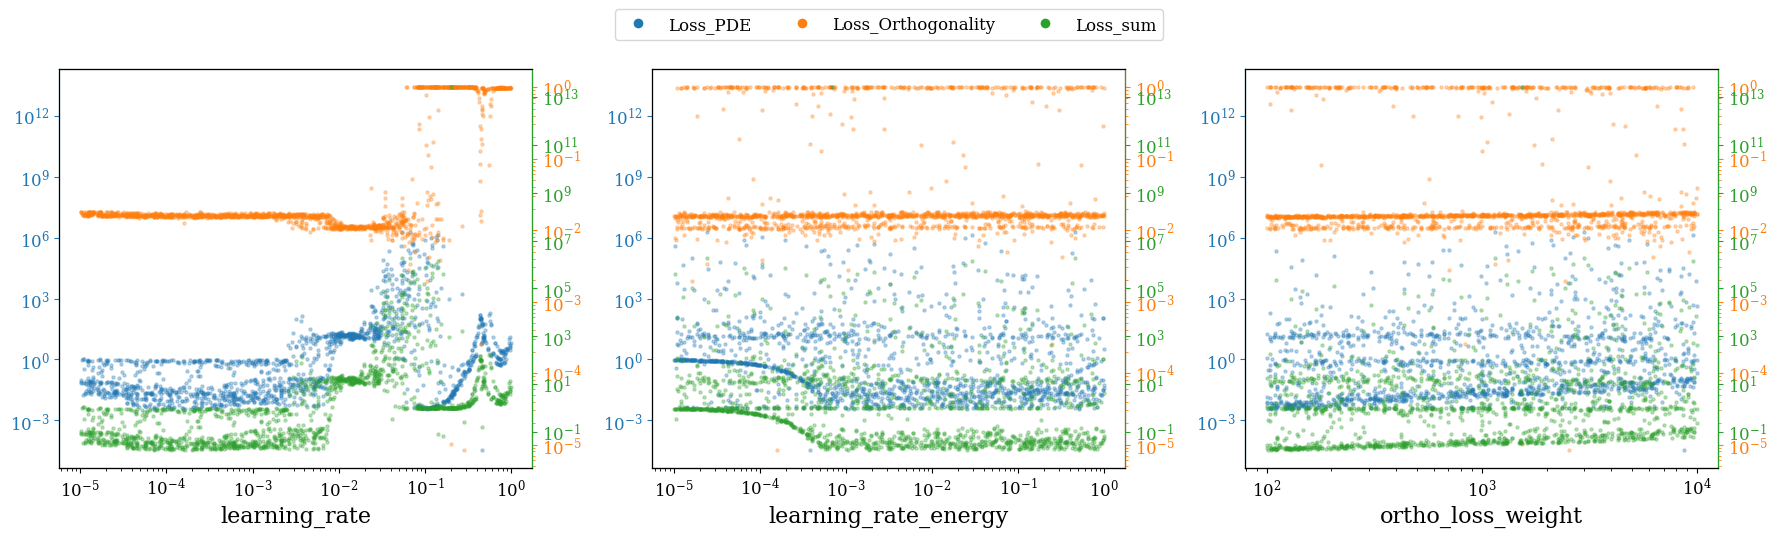

In [8]:
plot_random_search_metrics_twinx(df, metrics=["Loss_PDE", "Loss_Orthogonality", "Loss_sum"])

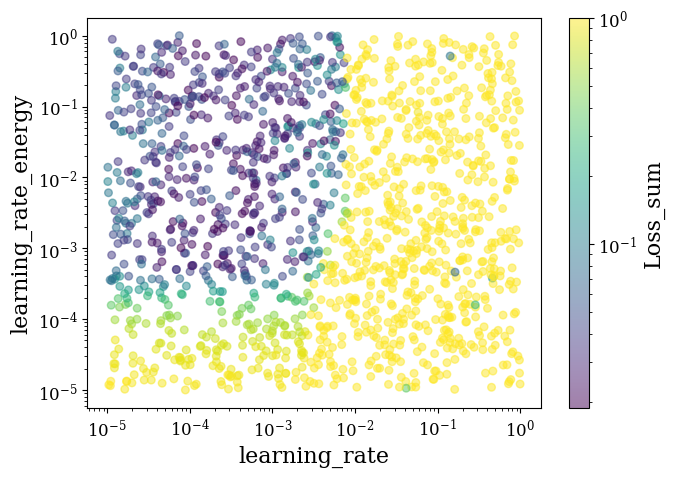

In [9]:
plot_colormap_plot(df, metrics=["Loss_sum"], x="learning_rate", y="learning_rate_energy", vmax=1e-0, s=30)

### Filter data
From the plots above we see that the best runs are where
- `learning_rate` <= 2e-3 and
- `learning_rate_energy` >= 6e-4,

so we will filter the data accordingly.

In [10]:
filters = [
    (df["learning_rate_energy"] >= 6e-4),
    (df["learning_rate"] <= 4e-3)
]
df2 = df.loc[pd.concat(filters, axis=1).all(axis=1)]

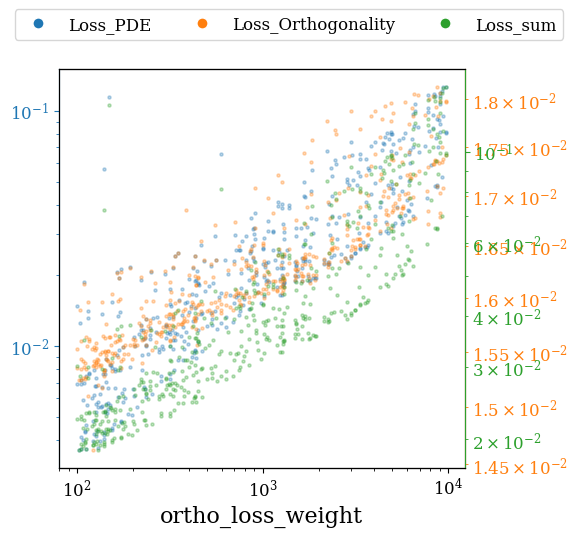

In [11]:
plot_random_search_metrics_twinx(df2, metrics=["Loss_PDE", "Loss_Orthogonality", "Loss_sum"], x_axes=["ortho_loss_weight"])

## Further search for best `ortho_loss_weight`
The Loss_sum seems to get better with lower `ortho_loss_weight`. We will extend the search for `ortho_loss_weight` in the range $[10^{-1}, 10^{2}]$.

We set
- `learning_rate` = $1\cdot10^{-4}$
- and `learning_rate_energy` = $1\cdot10^{-2}$,

which both are within the filter used above.

In [12]:
learning_rate = 1e-4
learning_rate_energy = 1e-2
ortho_loss_weight_values = np.logspace(-1, 2, 40)

In [13]:
%%skip_if LOAD_FROM_FILE
torch.manual_seed(124)
result = grid_search(
    train_func,
    metrics=[Loss_PDE(PotentialHarmonicOscillator()), Loss_Orthogonality([pinn1])],
    test_points=x_test,
    constant_parameters={
        "x_lim": x_lim,
        "ansatz_factor": ansatzfactor_HO_sym,
        "n_epochs": 3000,
        "E_init": 0.5,
        "verbose": False,

        "hidden_layers": 3,
        "width": 64,
        "lr": learning_rate,
        "lr_energy": learning_rate_energy,
    },
    sweep_parameters={
        "ortho_loss_weight": ortho_loss_weight_values,
    },
    generate_data_func=generate_data_func,
    n_repeats=5,
    seed=124,
)

In [14]:
filepath = "../data/ortho_loss_weight_search.npy"

# Save data to file
# np.save(filepath, result)

# Load data from file
if LOAD_FROM_FILE:
    result = np.load(filepath)

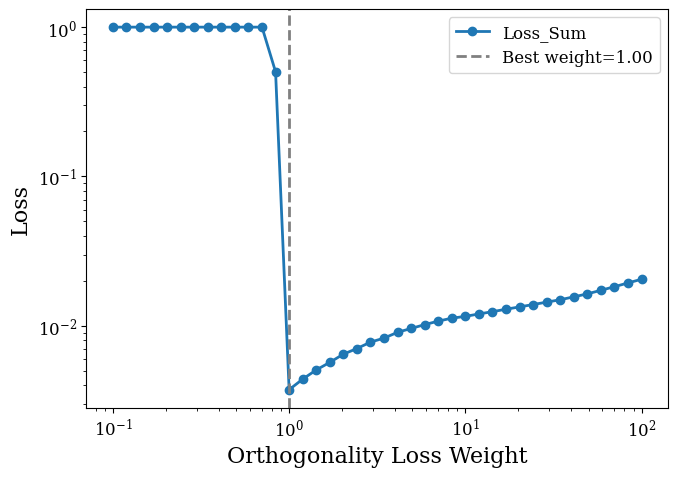

In [15]:
loss_pde, loss_orthogonality = result.T
loss_sum = loss_pde + loss_orthogonality

plt.figure(figsize=(7,5))
plt.plot(ortho_loss_weight_values, loss_sum, marker='o', label="Loss_Sum")

best_ortho_loss_weight = ortho_loss_weight_values[np.argmin(loss_sum)]
plt.axvline(x=best_ortho_loss_weight, color='gray', linestyle='--', label=f'Best weight={best_ortho_loss_weight:.2f}')

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Orthogonality Loss Weight")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("../figs/ortho_loss_weight_search.pdf")
plt.show()


Runs with `ortho_loss_weight` of less than $1.0$ fall to the ground state, indicated by the orthogonality loss being $\approx 1.0$. The PDE loss also decreases in this range, but that is not useful since the network is not learning the excited state.

We will choose a weight of $1.10$ to ensure we stay above this threshold.

## Grid search for best `learning_rate` and `learning_rate_energy`
We will now do a finer grid search over `learning_rate` and `learning_rate_energy` to find the best combination of these two hyperparameters.

We set `ortho_loss_weight` = $1.10$ based on the results above.

From the random search section we see that the Loss_sum decreases for lower `learning_rate` values and higher `learning_rate_energy` values. We therefore increase the search range for both parameters:
- `learning_rate`: $[1\cdot10^{-5}, 5\cdot10^{-3}]$
- `learning_rate_energy`: $[5\cdot10^{-4}, 5\cdot10^{-2}]$

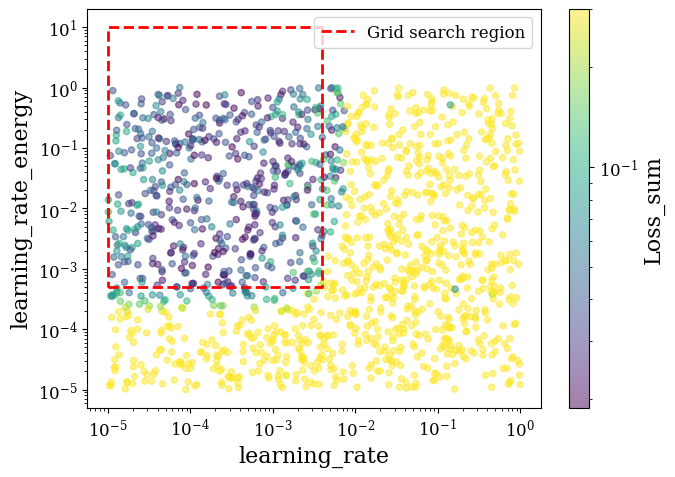

In [16]:
plot_colormap_plot(df, metrics=["Loss_sum"], x="learning_rate", y="learning_rate_energy", vmax=3e-1)

lr_min, lr_max = 1e-5, 4e-3
lr_energy_min, lr_energy_max = 5e-4, 1e+1
plt.plot([lr_min, lr_max, lr_max, lr_min, lr_min], [lr_energy_min, lr_energy_min, lr_energy_max, lr_energy_max, lr_energy_min], color='red', linestyle='--', label="Grid search region")
plt.legend()
plt.show()

In [17]:
ortho_loss_weight = 1.10
learning_rate_values = np.logspace(np.log10(lr_min), np.log10(lr_max), 10)
learning_rate_energy_values = np.logspace(np.log10(lr_energy_min), np.log10(lr_energy_max), 10)

In [18]:
%%skip_if LOAD_FROM_FILE
torch.manual_seed(124)
grid_result = grid_search(
    train_func,
    metrics=[Loss_PDE(PotentialHarmonicOscillator()), Loss_Orthogonality([pinn1])],
    test_points=x_test,
    constant_parameters={
        "x_lim": x_lim,
        "ansatz_factor": ansatzfactor_HO_sym,
        "n_epochs": 3000,
        "E_init": 0.5,
        "verbose": False,

        "hidden_layers": 3,
        "width": 64,
        "ortho_loss_weight": ortho_loss_weight,
    },
    sweep_parameters={
        "lr": learning_rate_values,
        "lr_energy": learning_rate_energy_values,
    },
    generate_data_func=generate_data_func,
    n_repeats=4,
    seed=124,
)

In [19]:
filepath = "../data/learning_rates_grid_search.npy"

# Save data to file
# np.save(filepath, grid_result)

# Load data from file
if LOAD_FROM_FILE:
    grid_result = np.load(filepath)

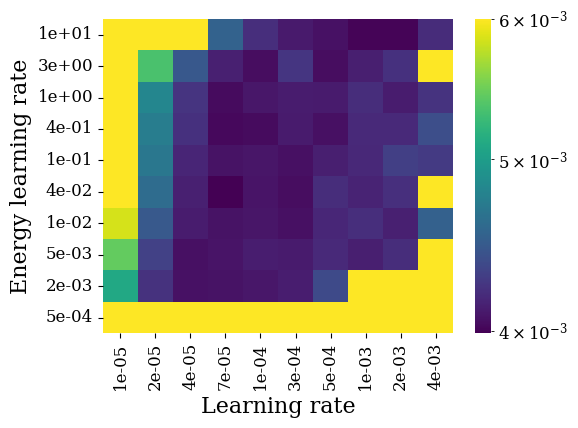

In [20]:
import seaborn as sns
from matplotlib.colors import LogNorm

# Heatmap of number of layers vs number of nodes
loss_pde, loss_orthogonality = grid_result[..., 0].T, grid_result[..., 1].T
loss_sum = loss_pde + loss_orthogonality
ax = sns.heatmap(
    loss_sum,
    # fmt=".4f",
    # annot=True,
    cmap="viridis",
    xticklabels=[f"{x:.0e}" for x in learning_rate_values],
    yticklabels=[f"{x:.0e}" for x in learning_rate_energy_values],
    norm=LogNorm(vmax=0.006)
)
ax.invert_yaxis()
plt.xlabel("Learning rate")
plt.ylabel("Energy learning rate")
plt.savefig("../figs/grid_search_learning_rates.pdf")
plt.show()

In [21]:
best_indices = np.unravel_index(np.argmin(loss_sum), loss_sum.shape)
best_lr = learning_rate_values[best_indices[1]]
best_lr_energy = learning_rate_energy_values[best_indices[0]]
print(f"Best learning rate: {best_lr:.2e}, Best energy learning rate: {best_lr_energy:.2e}")
print(f"Minimum Loss Sum: {loss_sum[best_indices]:.2e}")

Best learning rate: 7.37e-05, Best energy learning rate: 4.08e-02
Minimum Loss Sum: 3.99e-03


## Grid search number of layers and nodes
Next, we will do a grid search over the number of layers and nodes in the neural network.

The values we will test are:
- number of layers: [1, 2, 3, 4, 5, 6]
- number of nodes: [8, 16, 32, 64, 128, 256]

In [22]:
hidden_layers_values = [1, 2, 3, 4, 5, 6]
width_values = [8, 16, 32, 64, 128, 256]

In [23]:
%%skip_if LOAD_FROM_FILE
torch.manual_seed(124)
width_and_layers_result = grid_search(
    train_func,
    metrics=[Loss_PDE(PotentialHarmonicOscillator()), Loss_Orthogonality([pinn1])],
    test_points=x_test,
    constant_parameters={
        "x_lim": x_lim,
        "ansatz_factor": ansatzfactor_HO_sym,
        "n_epochs": 3000,
        "E_init": 0.5,
        "verbose": False,

        "lr": best_lr,
        "lr_energy": best_lr_energy,
        "ortho_loss_weight": ortho_loss_weight,
    },
    sweep_parameters={
        "hidden_layers": hidden_layers_values,
        "width": width_values,
    },
    generate_data_func=generate_data_func,
    n_repeats=30,
    seed=124,
)

In [24]:
filepath = "../data/width_and_layers_grid_search.npy"

# Save data to file
# np.save(filepath, width_and_layers_result)

# Load data from file
if LOAD_FROM_FILE:
    width_and_layers_result = np.load(filepath)

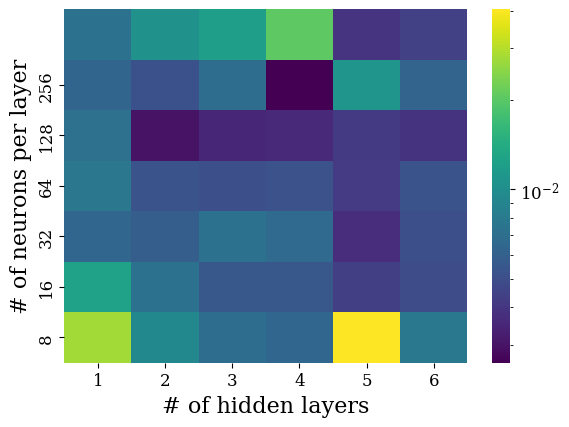

In [25]:
# Heatmap of number of layers vs number of nodes
loss_pde, loss_orthogonality = width_and_layers_result[..., 0].T, width_and_layers_result[..., 1].T
loss_sum = loss_pde + loss_orthogonality
ax = sns.heatmap(
    loss_sum,
    # fmt=".4f",
    # annot=True,
    cmap="viridis",
    xticklabels=hidden_layers_values,
    yticklabels=width_values,
    norm=LogNorm()
)
ax.invert_yaxis()
plt.xlabel("# of hidden layers")
plt.ylabel("# of neurons per layer")
plt.savefig("../figs/grid_search_width_and_layers.pdf")
plt.show()

In [26]:
best_indices = np.unravel_index(np.argmin(loss_sum), loss_sum.shape)
best_hidden_layers = hidden_layers_values[best_indices[1]]
best_width = width_values[best_indices[0]]
print(f"Best # hidden layers: {best_hidden_layers}, Best width: {best_width}")
print(f"Minimum Loss Sum: {loss_sum[best_indices]:.2e}")

Best # hidden layers: 4, Best width: 256
Minimum Loss Sum: 2.61e-03


## Activation functions
For now we have just used the `tanh` activation function for the hidden layers. We will now test other activation functions as well:
- `Tanh`
- `ReLU`
- `Sigmoid`

In [27]:
activation_func_values = [nn.Tanh, nn.ReLU, nn.Sigmoid]

In [28]:
%%skip_if LOAD_FROM_FILE
torch.manual_seed(124)
activation_func_result = grid_search(
    train_func,
    metrics=[Loss_PDE(PotentialHarmonicOscillator()), Loss_Orthogonality([pinn1])],
    test_points=x_test,
    constant_parameters={
        "x_lim": x_lim,
        "ansatz_factor": ansatzfactor_HO_sym,
        "n_epochs": 3000,
        "E_init": 0.5,
        "verbose": False,

        "lr": best_lr,
        "lr_energy": best_lr_energy,
        "ortho_loss_weight": ortho_loss_weight,
        "hidden_layers": best_hidden_layers,
        "width": best_width,
    },
    sweep_parameters={
        "activation_func": activation_func_values,
    },
    generate_data_func=generate_data_func,
    n_repeats=30,
    seed=124,
)

In [29]:
filepath = "../data/activation_func_search.npy"

# Save data to file
# np.save(filepath, activation_func_result)

# Load data from file
if LOAD_FROM_FILE:
    activation_func_result = np.load(filepath)

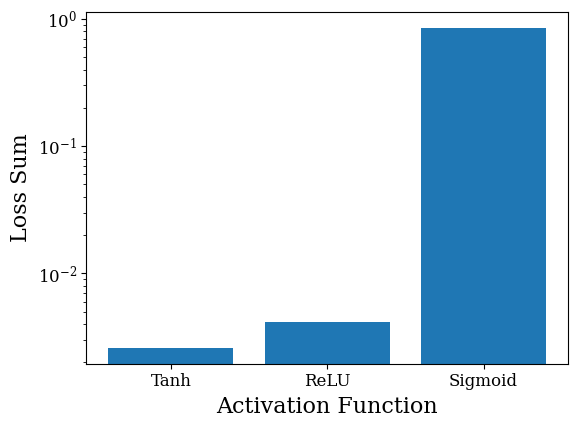

In [30]:
# Bar plot of activation functions
loss_pde, loss_orthogonality = activation_func_result[..., 0].T, activation_func_result[..., 1].T
loss_sum = loss_pde + loss_orthogonality

activation_func_names = [func.__name__ for func in activation_func_values]
plt.bar(activation_func_names, loss_sum)
plt.yscale("log")
plt.xlabel("Activation Function")
plt.ylabel("Loss Sum")
plt.savefig("../figs/activation_function_search.pdf")
plt.show()

In [31]:
best_index = np.argmin(loss_sum)
best_activation_func = activation_func_values[best_index]
print(f"Best activation function: {best_activation_func.__name__}")
print(f"Minimum Loss Sum: {loss_sum[best_index]:.2e}")

Best activation function: Tanh
Minimum Loss Sum: 2.61e-03


## Weight decay (regularization)
We have until now tested with `lambd` = 0. Now we want to see if regularization helps. We will test the for a broad range of `lambd` values, between $10^{-7}$ and $10^0$.

In [32]:
lambda_values = np.logspace(-7, 0, 15)

In [33]:
%%skip_if LOAD_FROM_FILE
torch.manual_seed(124)
lambda_search_result = grid_search(
    train_func,
    metrics=[Loss_PDE(PotentialHarmonicOscillator()), Loss_Orthogonality([pinn1])],
    test_points=x_test,
    constant_parameters={
        "x_lim": x_lim,
        "ansatz_factor": ansatzfactor_HO_sym,
        "n_epochs": 3000,
        "E_init": 0.5,
        "verbose": False,

        "lr": best_lr,
        "lr_energy": best_lr_energy,
        "ortho_loss_weight": ortho_loss_weight,
        "hidden_layers": best_hidden_layers,
        "width": best_width,
        "activation_func": best_activation_func,
    },
    sweep_parameters={
        "lambd": lambda_values,
    },
    generate_data_func=generate_data_func,
    n_repeats=10,
    seed=124,
)

In [34]:
filepath = "../data/lambda_search.npy"

# Save data to file
# np.save(filepath, activation_func_result)

# Load data from file
if LOAD_FROM_FILE:
    lambda_search_result = np.load(filepath)

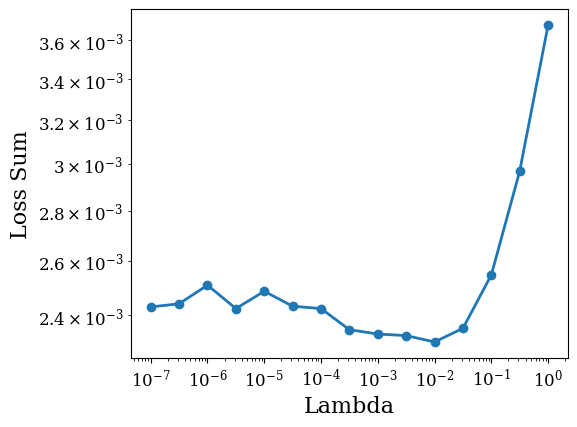

In [35]:
loss_pde, loss_orthogonality = lambda_search_result[..., 0].T, lambda_search_result[..., 1].T
loss_sum = loss_pde + loss_orthogonality

# Line plot of lambda values
plt.plot(lambda_values, loss_sum, marker='o')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Lambda")
plt.ylabel("Loss Sum")
plt.savefig("../figs/lambda_search.pdf")
plt.show()

In [36]:
best_index = np.argmin(loss_sum)
best_lambd = lambda_values[best_index]
print(f"Best lambda: {best_lambd:.2e}")
print(f"Minimum Loss Sum: {loss_sum[best_index]:.2e}")

Best lambda: 1.00e-02
Minimum Loss Sum: 2.31e-03


# Final test of best model
We have found that the best hyperparameters are:
- ortho loss weight: 1.10,
- learning rate: 7.37e-5, 
- energy learning rate: 4.08e-2,
- hidden layers: 4,
- hidden layer nodes: 256,
- activation function: Tanh,
- weight decay (lambd): 1e-2.

Now we will evaluate this final model, and check how well it finds the first excited state of the 1D quantum harmonic oscillator.

In [ ]:
torch.manual_seed(124)
x_train = generate_input_data(256, x_lim, device)

model = train_func(
    x=x_train,
    x_lim=x_lim,
    ansatz_factor=ansatzfactor_HO_sym,
    n_epochs=3000,
    E_init=0.5,
    device=device,

    lr=best_lr,
    lr_energy=best_lr_energy,
    ortho_loss_weight=ortho_loss_weight,
    hidden_layers=best_hidden_layers,
    width=best_width,
    activation_func=best_activation_func,
    lambd=best_lambd,
    verbose=True
)

Epoch 100/3000. Best loss=9.555e-03. Current loss=9.555e-03. E=1.505832
Epoch 200/3000. Best loss=1.487e-03. Current loss=1.487e-03. E=1.496096
Epoch 300/3000. Best loss=7.154e-04. Current loss=7.154e-04. E=1.497235


In [ ]:
x_values = torch.from_numpy(np.linspace(x_lim[0], x_lim[1], 256)).float().to(device).unsqueeze(-1)
compare_analytic(x_values, x_lim, model, n=1, show=False)
plt.savefig("../figs/final_pinn_1st_excited_state.pdf")
plt.show()

TypeError: compare_analytic() got an unexpected keyword argument 'show'